In [2]:
data = pd.read_csv(
    r"C:\Users\abera\Downloads\WA_FnUseC_TelcoCustomerChurn.csv"
)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.options.display.float_format = '{:.2f}'.format

import warnings
warnings.filterwarnings('ignore')

In [9]:
non_convertible_values = data[
    data['TotalCharges'] == ' '
]['TotalCharges']

print(
    "Non-convertible values:",
    non_convertible_values.unique()
)

data['TotalCharges'] = data[
    'TotalCharges'
].replace(' ', np.nan)

data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'],
    errors='coerce'
)

data['TotalCharges'].fillna(
    data['TotalCharges'].median(),
    inplace=True
)

Non-convertible values: []


0        29.85
1      1889.50
2       108.15
3      1840.75
4       151.65
         ...  
7038   1990.50
7039   7362.90
7040    346.45
7041    306.60
7042   6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
data.drop(
    columns=['customerID'],
    inplace=True
)

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
data.to_csv(
    'cleaned_telco_churn.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [12]:
duplicate_rows = data.duplicated().sum()

print(
    "Duplicate Rows:",
    duplicate_rows
)

Duplicate Rows: 22


In [13]:
data.drop_duplicates(
    inplace=True
)

print(
    "Duplicates removed successfully."
)

print(data.shape)

Duplicates removed successfully.
(7021, 20)


In [14]:
data.columns = [
    col.strip().replace(' ', '_')
    for col in data.columns
]

data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [15]:
for col in data.select_dtypes(
    include='object'
).columns:
    
    data[col] = data[col].str.strip()

print("Whitespace cleaned.")

Whitespace cleaned.


In [16]:
print(
    data.dtypes
)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [17]:
missing_values = data.isnull().sum()

print(missing_values)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


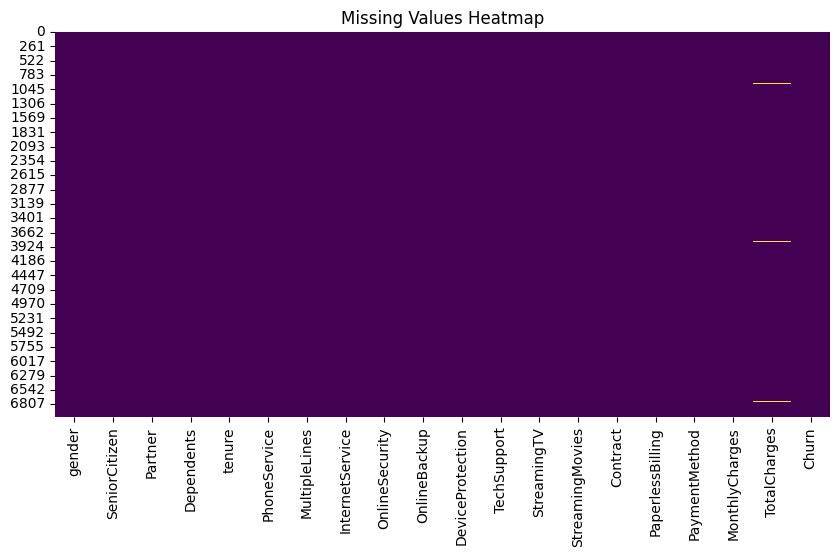

In [18]:
plt.figure(figsize=(10,5))

sns.heatmap(
    data.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title(
    'Missing Values Heatmap'
)

plt.show()

In [19]:
for col in data.columns:
    
    print(
        f"\nColumn: {col}"
    )
    
    print(
        data[col].unique()
    )


Column: gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Column: SeniorCitizen
[0 1]

Column: Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Column: PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

Column: InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Column: OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Column: OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

Column: DeviceProtection
<ArrowStri

In [20]:
print(
    data['Churn'].value_counts()
)

Churn
No     5164
Yes    1857
Name: count, dtype: int64


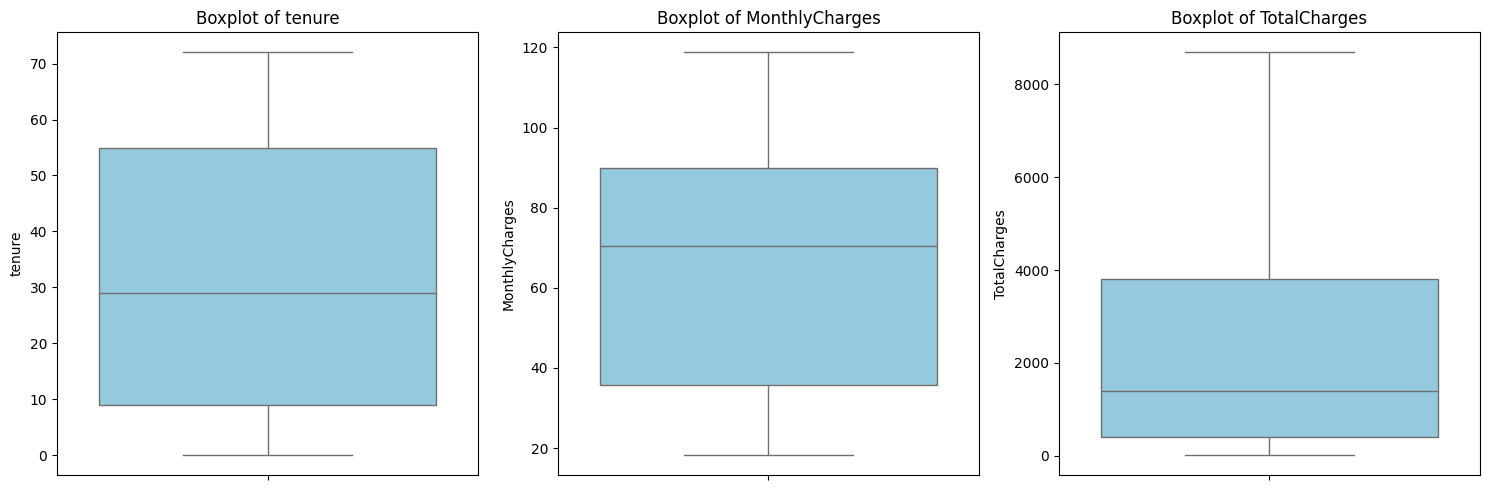

In [21]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols):
    
    plt.subplot(1,3,i+1)
    
    sns.boxplot(
        y=data[col],
        color='skyblue'
    )
    
    plt.title(f'Boxplot of {col}')

plt.tight_layout()

plt.show()

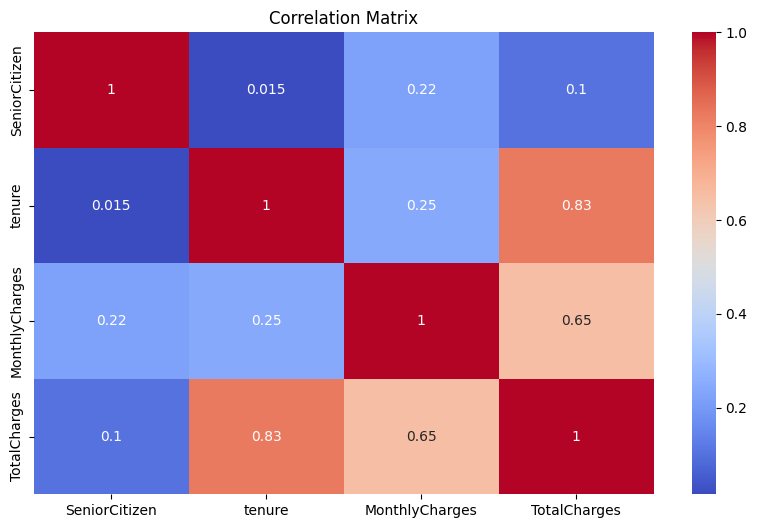

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.corr(
        numeric_only=True
    ),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

In [23]:
print(
    "Final Dataset Shape:",
    data.shape
)

Final Dataset Shape: (7021, 20)


In [24]:
data.to_csv(
    'cleaned_telco_churn.csv',
    index=False
)

print(
    "Final cleaned dataset saved successfully."
)

Final cleaned dataset saved successfully.
